## Fig 3

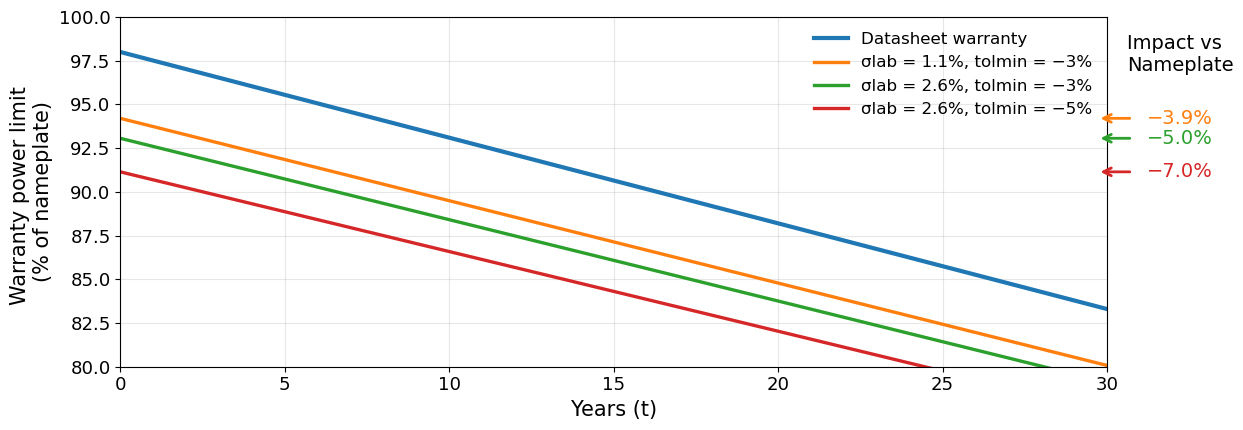

In [13]:
 import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Inputs (edit these)
# -----------------------
years = 30
Ly1 = -0.02      # first-year loss (e.g., -0.02 for 2%)
DR  = -0.005     # linear degradation rate per year (e.g., -0.005 for -0.5%/yr)

# Detailed clause scenarios: (label, sigma_lab %, tolmin % (negative))
scenarios = [
    ("Datasheet warranty", None, None),
    ("σlab = 1.1%, tolmin = −3%", 1.1, -3),
    ("σlab = 2.6%, tolmin = −3%", 2.6, -3),
    ("σlab = 2.6%, tolmin = −5%", 2.6, -5),
]

# Impacts you want displayed (as text) for the three detailed curves, in same order
impact_labels = ["−3.9%", "−5.0%", "−7.0%"]


# -----------------------
# Helper: detailed clause multiplier
# -----------------------
def detailed_multiplier(tolmin_percent, sigmalab_percent):
    tol_abs = abs(tolmin_percent) / 100.0
    sigma   = sigmalab_percent / 100.0
    return (1 - tol_abs) / (1 + (1.65/2) * sigma)


# -----------------------
# Compute curves (P_w(t) / Pnp in %)
# INCLUDING Ly1, but plotted on a y-axis that tops at 100
# -----------------------
t = np.linspace(0, years, years * 12 + 1)  # monthly resolution

# Datasheet: starts at 100*(1+Ly1) at t=0
base = 100 * (1 + Ly1) * (1 + DR * t)

curves = []
detailed_starts = []  # store y at t=0 for orange/green/red

for label, sig, tol in scenarios:
    if sig is None:
        y = base
    else:
        y = base * detailed_multiplier(tol, sig)
        detailed_starts.append(y[0])
    curves.append((label, y, sig, tol))


# -----------------------
# Plot styling: wide + short, bigger fonts
# -----------------------
fig, ax = plt.subplots(figsize=(12.5, 4.4))
fig.subplots_adjust(right=0.78)

for label, y, sig, tol in curves:
    lw = 3.0 if sig is None else 2.4
    plt.plot(t, y, linewidth=lw, label=label)

plt.xlabel("Years (t)", fontsize=15)
plt.ylabel("Warranty power limit \n(% of nameplate)", fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.grid(True, alpha=0.30)

ax.set_xlim(0, years)
ax.set_ylim(80, 100)

plt.legend(fontsize=12, frameon=False, loc="upper right")

# Header (keep neutral / black)
ax.text(
    1.02, 0.95,
    "Impact vs\nNameplate",
    transform=ax.transAxes,
    fontsize=14,
    va="top"
)

labels = ["−3.9%", "−5.0%", "−7.0%"]

# Explicit colors to match matplotlib defaults
colors = ["tab:orange", "tab:green", "tab:red"]

# Arrow tip near right edge of plot
x_tip = years - 0.2

for y0, lab, col in zip(detailed_starts, labels, colors):
    ax.annotate(
        lab,
        xy=(x_tip, y0),                        # arrow tip at right edge
        xycoords=("data", "data"),
        xytext=(1.04, y0),                     # text just outside axes
        textcoords=("axes fraction", "data"),
        fontsize=14,
        va="center",
        ha="left",
        color=col,
        arrowprops=dict(
            arrowstyle="->",
            lw=2,
            color=col,
            shrinkA=10,   # keeps arrow from starting inside text
            shrinkB=0
        )
    )


#plt.title("STC Power Warranty Limits: Datasheet vs Detailed Clause", fontsize=18, loc="left")
plt.tight_layout()
plt.show()


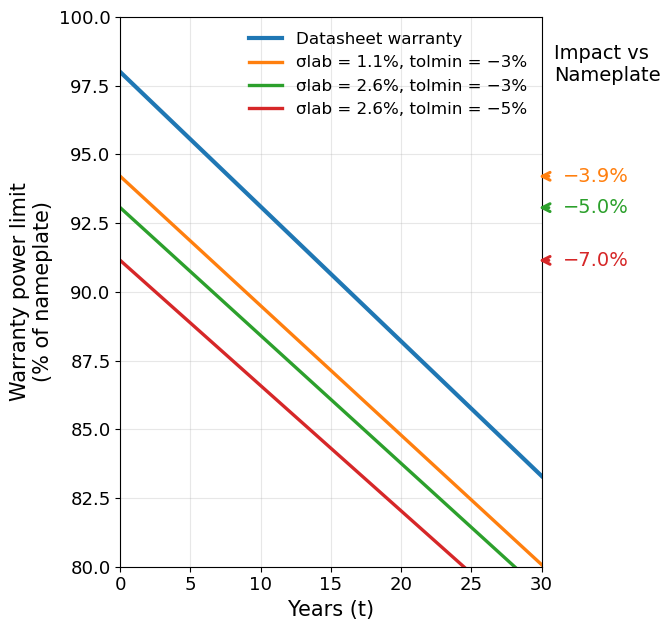

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Inputs
# -----------------------
years = 30
Ly1 = -0.02
DR  = -0.005

scenarios = [
    ("Datasheet warranty", None, None),
    ("σlab = 1.1%, tolmin = −3%", 1.1, -3),
    ("σlab = 2.6%, tolmin = −3%", 2.6, -3),
    ("σlab = 2.6%, tolmin = −5%", 2.6, -5),
]

impact_labels = ["−3.9%", "−5.0%", "−7.0%"]

def detailed_multiplier(tolmin_percent, sigmalab_percent):
    tol_abs = abs(tolmin_percent) / 100.0
    sigma   = sigmalab_percent / 100.0
    return (1 - tol_abs) / (1 + (1.65/2) * sigma)

# -----------------------
# Curves
# -----------------------
t = np.linspace(0, years, years * 12 + 1)
base = 100 * (1 + Ly1) * (1 + DR * t)

curves = []
detailed_starts = []
for label, sig, tol in scenarios:
    if sig is None:
        y = base
    else:
        y = base * detailed_multiplier(tol, sig)
        detailed_starts.append(y[0])
    curves.append((label, y, sig, tol))

# -----------------------
# Figure: square + big fonts
# -----------------------
fig, ax = plt.subplots(figsize=(6.8, 6.4))
fig.subplots_adjust(right=0.70)

for label, y, sig, tol in curves:
    lw = 3.0 if sig is None else 2.4
    ax.plot(t, y, linewidth=lw, label=label)

ax.set_xlim(0, years)
ax.set_ylim(80, 100)

ax.set_xlabel("Years (t)", fontsize=15)
ax.set_ylabel("Warranty power limit\n(% of nameplate)", fontsize=15)

ax.tick_params(axis="both", labelsize=13)
ax.grid(True, alpha=0.30)

ax.legend(fontsize=12, frameon=False, loc="upper right")

# -----------------------
# Right-side annotation (bigger fonts)
# -----------------------
ax.text(
    1.03, 0.95,
    "Impact vs\nNameplate",
    transform=ax.transAxes,
    fontsize=14,
    va="top"
)

colors = ["tab:orange", "tab:green", "tab:red"]
x_tip = years - 0.2

for y0, lab, col in zip(detailed_starts, impact_labels, colors):
    ax.annotate(
        lab,
        xy=(x_tip, y0),
        xycoords=("data", "data"),
        xytext=(1.05, y0),
        textcoords=("axes fraction", "data"),
        fontsize=14,
        va="center",
        ha="left",
        color=col,
        arrowprops=dict(
            arrowstyle="->",
            lw=2.2,
            color=col,
            shrinkA=8,
            shrinkB=0
        )
    )

plt.tight_layout()
plt.show()


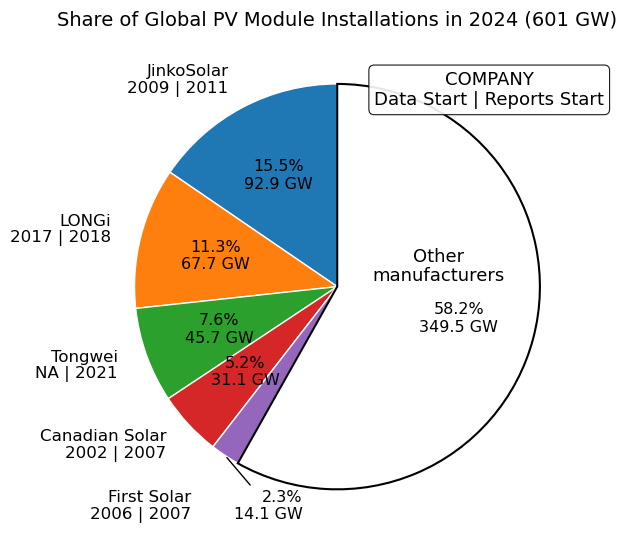

In [62]:
import matplotlib.pyplot as plt
import numpy as np


plt.rcParams.update({
    "font.size": 35,          # base font
    "axes.titlesize": 35,
    "axes.labelsize": 35,
    "xtick.labelsize": 35,
    "ytick.labelsize": 35,
    "legend.fontsize": 35,
})


# -----------------------
# Inputs from your table
# -----------------------
# (Company, 2024 module sales (GW), First year of data, First year of annual report)
companies = [
    ("JinkoSolar",      92.87, "2009", "2011"),
    ("LONGi",           67.69, "2017", "2018"),
    ("Tongwei",         45.71, "NA",   "2021"),
    ("Canadian Solar",  31.10, "2002", "2007"),
    ("First Solar",     14.10, "2006", "2007"),
]

total_global = 601.0  # GW installed in 2024

# Values for pie (GW)
values_companies = [c[1] for c in companies]
other = total_global - sum(values_companies)
values = values_companies + [other]

# Outside labels (next to slices) ONLY for companies (NOT "Other manufacturers")
outer_labels = [f"{c[0]}\n{c[2]} | {c[3]}" for c in companies]

# -----------------------
# Inside labels: % + GW
# -----------------------
def autopct_with_gw(values):
    def inner(pct):
        total = sum(values)
        gw = pct / 100.0 * total
        return f"{pct:.1f}%\n{gw:.1f} GW"
    return inner

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(6.8, 6.6))

wedges, _, autotexts = ax.pie(
    values,
    startangle=90,
    autopct=autopct_with_gw(values),
    pctdistance=0.62,
    wedgeprops=dict(edgecolor="white", linewidth=1)
)

# Make "Other manufacturers" slice white with dark outline
w_other = wedges[-1]
w_other.set_facecolor("white")
w_other.set_edgecolor("black")
w_other.set_linewidth(1.5)


# Style inside-slice text
for at in autotexts:
    at.set_fontsize(11.5)
    at.set_ha("center")
    at.set_va("center")

# -----------------------
# Place company labels next to slices (exclude "Other manufacturers")
# -----------------------
for wedge, label in zip(wedges[:-1], outer_labels):
    angle = (wedge.theta2 + wedge.theta1) / 2.0
    angle_rad = np.deg2rad(angle)

    # default label radius for company names
    r = 1.15

    # nudge First Solar outward to avoid overlap (small slice)
    if "First Solar" in label:
        r = 1.30

    x = r * np.cos(angle_rad)
    y = r * np.sin(angle_rad)

    ha = "left" if x > 0 else "right"

    ax.text(
        x, y,
        label,
        ha=ha,
        va="center",
        fontsize=12,
        linespacing=1.15
    )

# -----------------------
# Put "Other manufacturers" label INSIDE its slice (to remove white space to the right)
# -----------------------
w_other = wedges[-1]
angle_other = (w_other.theta2 + w_other.theta1) / 2.0
angle_other_rad = np.deg2rad(angle_other)

r_other_label = 0.35  # inside the pie; tweak 0.30–0.50 if needed
x_other = r_other_label * np.cos(angle_other_rad)
y_other = r_other_label * np.sin(angle_other_rad)


# -----------------------
# Move First Solar % + GW outside with leader line (to avoid overlap in the small slice)
# -----------------------
# Find index of First Solar wedge (same order as companies list)
first_solar_idx = [c[0] for c in companies].index("First Solar")
w_fs = wedges[first_solar_idx]
at_fs = autotexts[first_solar_idx]

# Hide inside label for First Solar only
at_fs.set_visible(False)

# Leader line anchor on pie edge
angle_fs = (w_fs.theta2 + w_fs.theta1) / 2.0
angle_fs_rad = np.deg2rad(angle_fs)

x0 = np.cos(angle_fs_rad)
y0 = np.sin(angle_fs_rad)

# Callout position controls (THIS is what you tweak)
r_callout = 1.30  # closer to the circle; adjust 1.20–1.45
dx = 0.06         # nudge to the right (positive) / left (negative)
dy = 0.00         # nudge up/down

x1 = r_callout * np.cos(angle_fs_rad) + dx
y1 = r_callout * np.sin(angle_fs_rad) + dy

# End of leader line / text position
x1 = 0.40 * np.cos(angle_rad) + 0.05
y1 = 1.30 * np.sin(angle_rad)

fs_gw = companies[first_solar_idx][1]
fs_pct = 100.0 * fs_gw / total_global

ax.annotate(
    f"{fs_pct:.1f}%\n{fs_gw:.1f} GW",
    xy=(x0, y0),
    xytext=(x1, y1),
    ha="left" if x1 > 0 else "right",
    va="center",
    fontsize=11.5,
    arrowprops=dict(arrowstyle="-", lw=1.0)
)

# -----------------------
# Legend header box ONLY (no entries)
# -----------------------
ax.text(
    0.8, 0.85,
    "COMPANY\nData Start | Reports Start",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.30", facecolor="white", alpha=0.90, linewidth=0.8)
)

x_other =+0.5
y_other =+0.1
ax.text(
    x_other, y_other,
    "Other\nmanufacturers",
    ha="center",
    va="center",
    fontsize=13,
    linespacing=1.05
)



ax.set_title("Share of Global PV Module Installations in 2024 (601 GW)", fontsize=14)
plt.tight_layout()
plt.show()
